In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"C:\Users\Hp\Downloads\FMCG_Supply_Chain_Bullwhip_Data.csv")
# Preview the data
print(df.head())


      Date Region     SKU  Raw_Material_Ordered  Production_Qty  \
0  2023-01  North    Cola                  1684            1193   
1  2023-01  North  Orange                  1923            1622   
2  2023-01  North   Lemon                  1956            1833   
3  2023-01  North   Water                  1334             973   
4  2023-01  South    Cola                  1939            1826   

   Delivery_Delay_Days  Dispatch_Qty  Retailer_Order_Qty  Sales_Qty  \
0                    2          1100                 981        892   
1                    2          1494                1646       1620   
2                    4          1735                1969       1914   
3                    4           906                 745        705   
4                    4          1717                1897       1864   

   Wholesaler_Inventory  Retailer_Inventory Promotion_Event  Unit_Cost  \
0                   748                 451             Yes       0.33   
1                   53

In [12]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort data by Date for proper time series processing
df = df.sort_values(by='Date')

# Check data types
print(df.dtypes)


Date                    datetime64[ns]
Region                          object
SKU                             object
Raw_Material_Ordered             int64
Production_Qty                   int64
Delivery_Delay_Days              int64
Dispatch_Qty                     int64
Retailer_Order_Qty               int64
Sales_Qty                        int64
Wholesaler_Inventory             int64
Retailer_Inventory               int64
Promotion_Event                 object
Unit_Cost                      float64
Unit_Price                     float64
dtype: object


In [13]:
# Get an overview of columns
print(df.columns)

# Summary stats
print(df.describe())

# Unique SKUs and Regions
print("SKU Categories:", df['SKU'].unique())
print("Regions:", df['Region'].unique())

Index(['Date', 'Region', 'SKU', 'Raw_Material_Ordered', 'Production_Qty',
       'Delivery_Delay_Days', 'Dispatch_Qty', 'Retailer_Order_Qty',
       'Sales_Qty', 'Wholesaler_Inventory', 'Retailer_Inventory',
       'Promotion_Event', 'Unit_Cost', 'Unit_Price'],
      dtype='object')
                      Date  Raw_Material_Ordered  Production_Qty  \
count                  384            384.000000      384.000000   
mean   2023-12-16 10:00:00           1987.205729     1696.484375   
min    2023-01-01 00:00:00           1001.000000      594.000000   
25%    2023-06-23 12:00:00           1515.500000     1196.000000   
50%    2023-12-16 12:00:00           2002.500000     1698.500000   
75%    2024-06-08 12:00:00           2460.000000     2133.250000   
max    2024-12-01 00:00:00           2997.000000     2830.000000   
std                    NaN            556.775181      575.077091   

       Delivery_Delay_Days  Dispatch_Qty  Retailer_Order_Qty    Sales_Qty  \
count           384.000000

In [14]:
# Convert to datetime and extract year, month, and season
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df['Season'] = df['Month'].map({
    12: 'Winter', 1: 'Winter', 2: 'Winter',
    3: 'Spring', 4: 'Spring', 5: 'Spring',
    6: 'Summer', 7: 'Summer', 8: 'Summer',
    9: 'Fall', 10: 'Fall', 11: 'Fall'
})

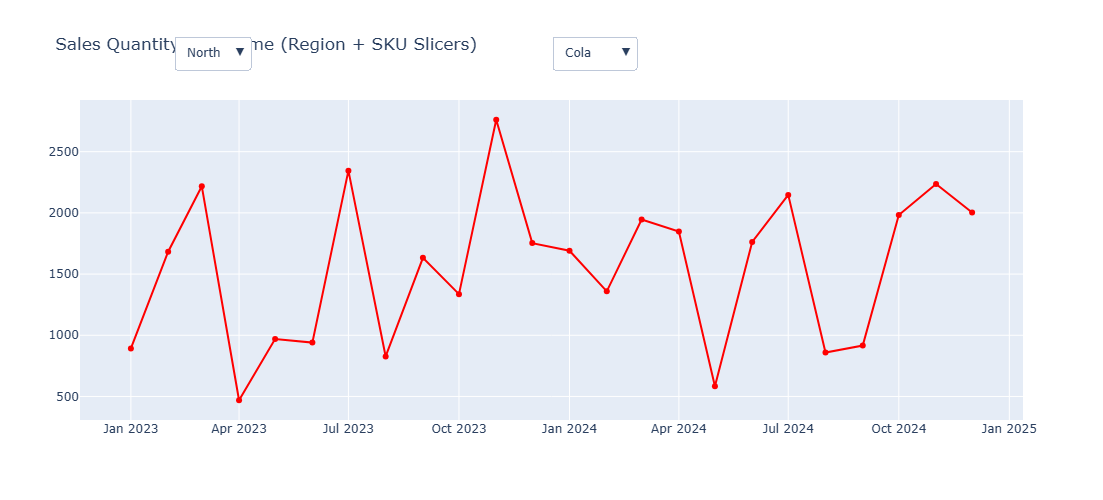

In [25]:
import plotly.graph_objects as go

# Custom color map
color_map = {
    'Cola': '#FF0000',     # Red
    'Water': '#0000FF',    # Blue
    'Lemon': '#FFFF00',    # Yellow
    'Orange': '#FFA500',   # Orange
    'Default': '#19D3F3'   # Light Blue fallback
}

# Initial selection
initial_region = 'North'
initial_sku = 'Cola'

# Filtered DataFrame
df_filtered = df[(df['Region'] == initial_region) & (df['SKU'] == initial_sku)]

# Get color
color = color_map.get(initial_sku, color_map['Default'])

# Create figure
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=df_filtered['Date'],
    y=df_filtered['Sales_Qty'],
    mode='lines+markers',
    name=f'{initial_sku} in {initial_region}',
    line=dict(color=color)
))

# Add Region dropdown
fig.update_layout(
    title='Sales Quantity Over Time (Region + SKU Slicers)',
    updatemenus=[
        {
            "buttons": [
                {
                    "label": region,
                    "method": "update",
                    "args": [
                        {
                            "x": [df[(df['Region'] == region) & (df['SKU'] == initial_sku)]['Date']],
                            "y": [df[(df['Region'] == region) & (df['SKU'] == initial_sku)]['Sales_Qty']],
                            "line.color": color_map.get(initial_sku, color_map['Default'])
                        },
                        {"title": f"Sales Quantity Over Time: {initial_sku} in {region}"}
                    ]
                } for region in df['Region'].unique()
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.1,
            "y": 1.2,
            "xanchor": "left",
            "yanchor": "top"
        },
        {
            "buttons": [
                {
                    "label": sku,
                    "method": "update",
                    "args": [
                        {
                            "x": [df[(df['Region'] == initial_region) & (df['SKU'] == sku)]['Date']],
                            "y": [df[(df['Region'] == initial_region) & (df['SKU'] == sku)]['Sales_Qty']],
                            "line.color": color_map.get(sku, color_map['Default'])
                        },
                        {"title": f"Sales Quantity Over Time: {sku} in {initial_region}"}
                    ]
                } for sku in df['SKU'].unique()
            ],
            "direction": "down",
            "showactive": True,
            "x": 0.5,
            "y": 1.2,
            "xanchor": "left",
            "yanchor": "top"
        }
    ]
)

fig.update_layout(height=500)
fig.show()


In [15]:
## problem metrics gap
df['Raw_Material_Gap'] = df['Raw_Material_Ordered'] - df['Production_Qty']
df['Production_Gap'] = df['Production_Qty'] - df['Dispatch_Qty']
df['Retail_Distortion'] = df['Retailer_Order_Qty'] - df['Sales_Qty']
df['Inventory_Gap'] = (df['Wholesaler_Inventory'] + df['Retailer_Inventory']) - df['Sales_Qty']
df['Dispatch_Gap'] = df['Retailer_Order_Qty'] - df['Dispatch_Qty']
df['Sales_Fulfillment_Gap'] = df['Dispatch_Qty'] - df['Sales_Qty']


In [22]:
sns.set(style='whitegrid')
def plot_line_chart(data, x, y, hue, title, xlabel, ylabel, rotation=45):
    plt.figure(figsize=(9, 5))
    sns.lineplot(data=data, x=x, y=y, hue=hue, marker='o')
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.xticks(rotation=rotation)
    plt.tight_layout()
    plt.show()

In [23]:
def plot_bar_chart(data, x, y, hue, title, xlabel, ylabel):
    plt.figure(figsize=(9, 5))
    sns.barplot(data=data, x=x, y=y, hue=hue, estimator=np.mean, ci=None)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

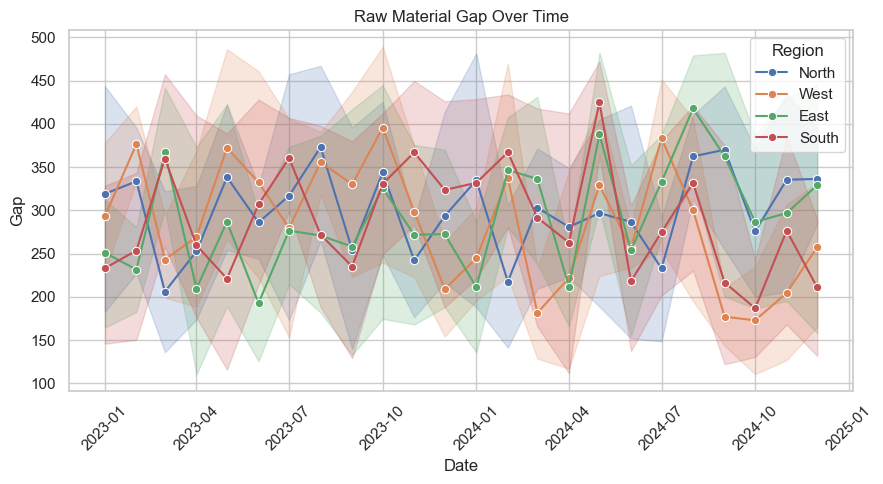

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




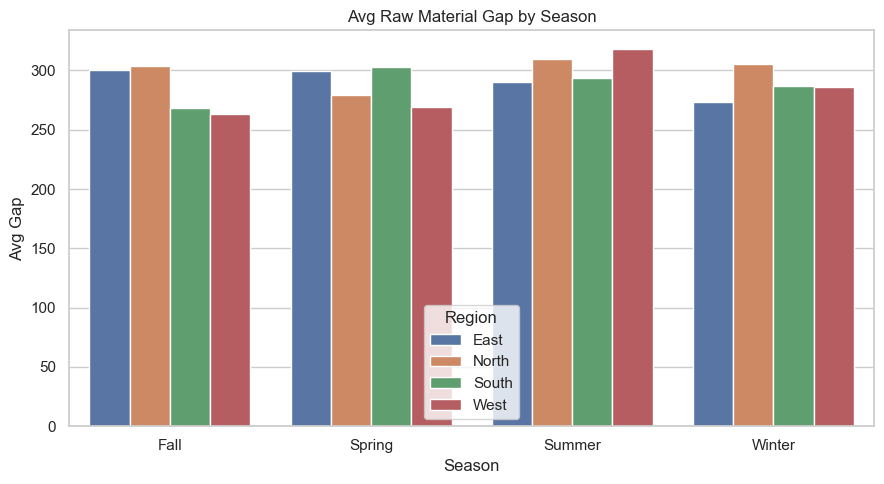

In [24]:
plot_line_chart(df, 'Date', 'Raw_Material_Gap', 'Region',
                "Raw Material Gap Over Time", "Date", "Gap")
raw_material_season = df.groupby(['Season', 'Region'])['Raw_Material_Gap'].mean().reset_index()
plot_bar_chart(raw_material_season, 'Season', 'Raw_Material_Gap', 'Region',
               "Avg Raw Material Gap by Season", "Season", "Avg Gap")


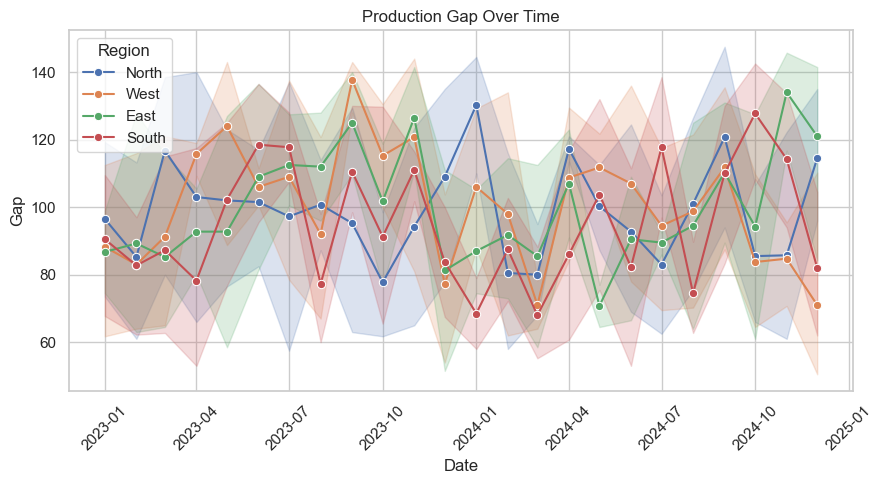

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




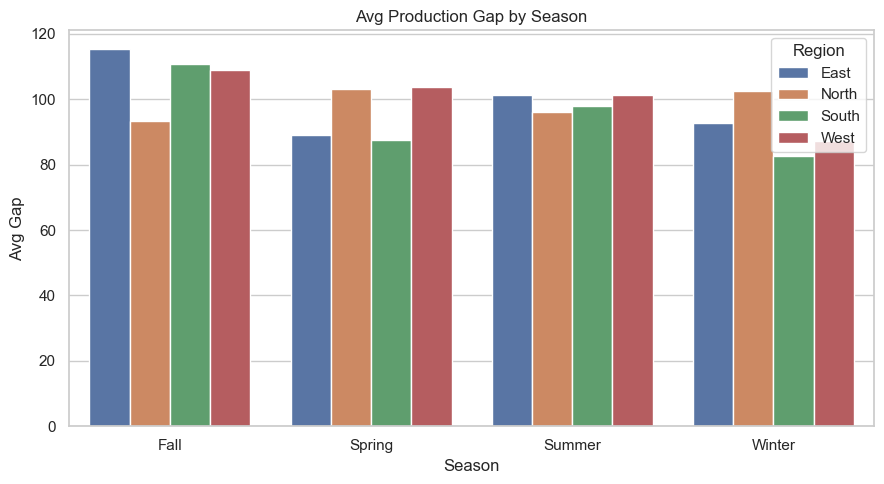

In [26]:
plot_line_chart(df, 'Date', 'Production_Gap', 'Region',
                "Production Gap Over Time", "Date", "Gap")
production_season = df.groupby(['Season', 'Region'])['Production_Gap'].mean().reset_index()
plot_bar_chart(production_season, 'Season', 'Production_Gap', 'Region',
               "Avg Production Gap by Season", "Season", "Avg Gap")


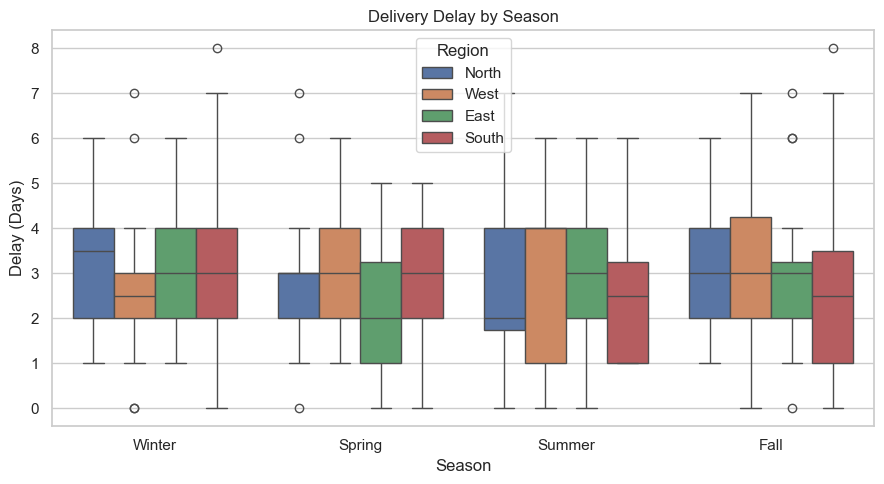

In [32]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df, x='Season', y='Delivery_Delay_Days', hue='Region')
plt.title("Delivery Delay by Season")
plt.xlabel("Season")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()


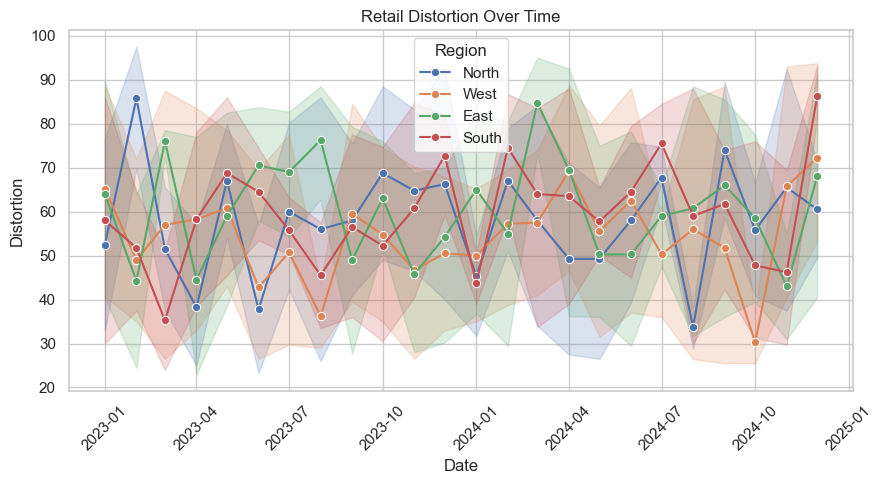

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




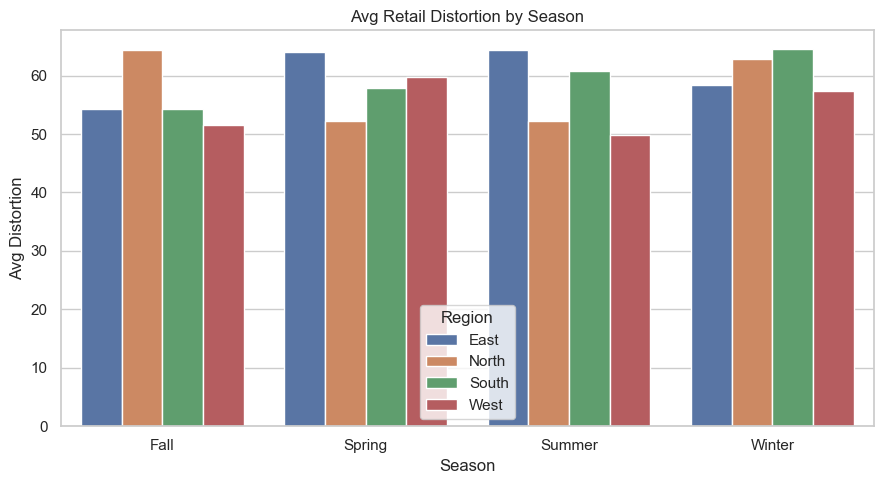

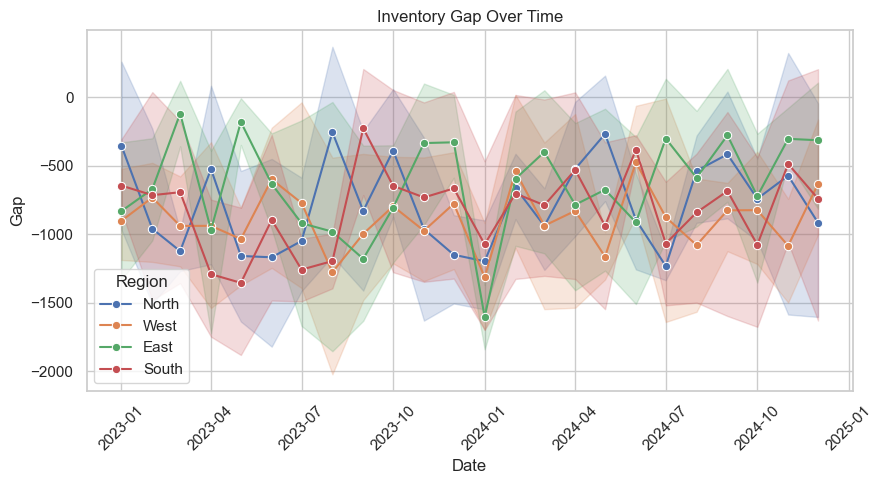

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




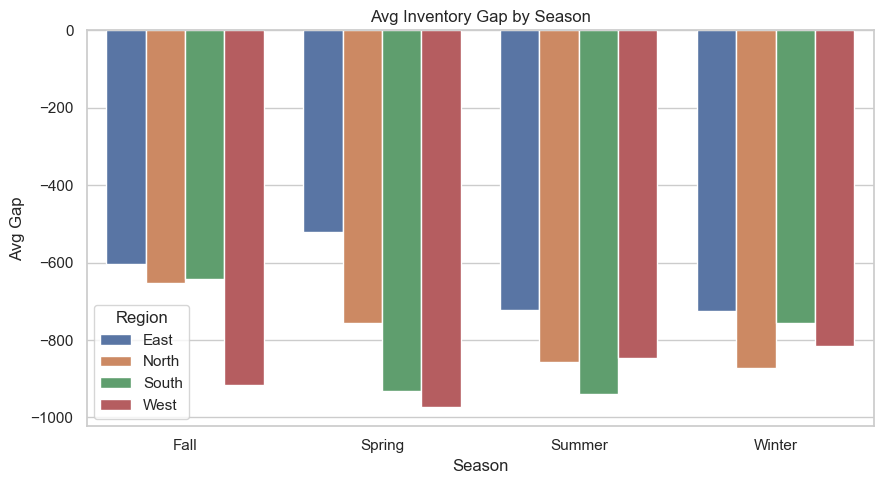

In [29]:
plot_line_chart(df, 'Date', 'Inventory_Gap', 'Region',
                "Inventory Gap Over Time", "Date", "Gap")
inventory_season = df.groupby(['Season', 'Region'])['Inventory_Gap'].mean().reset_index()
plot_bar_chart(inventory_season, 'Season', 'Inventory_Gap', 'Region',
               "Avg Inventory Gap by Season", "Season", "Avg Gap")


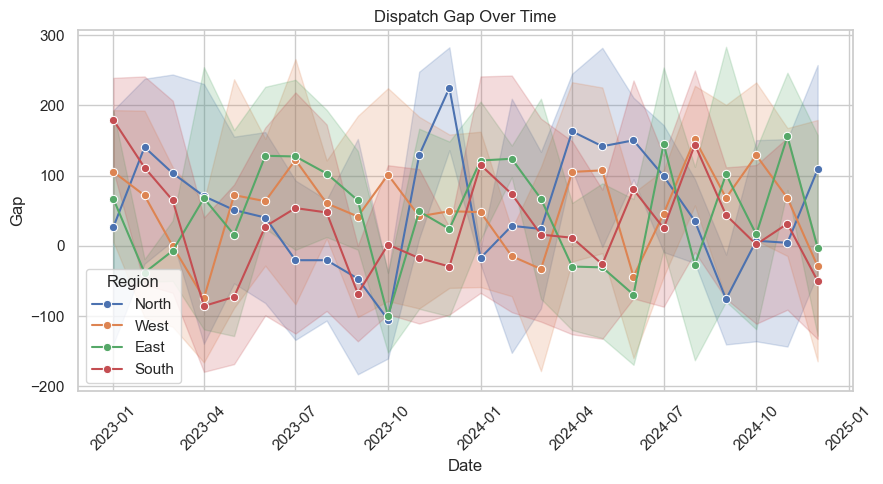

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




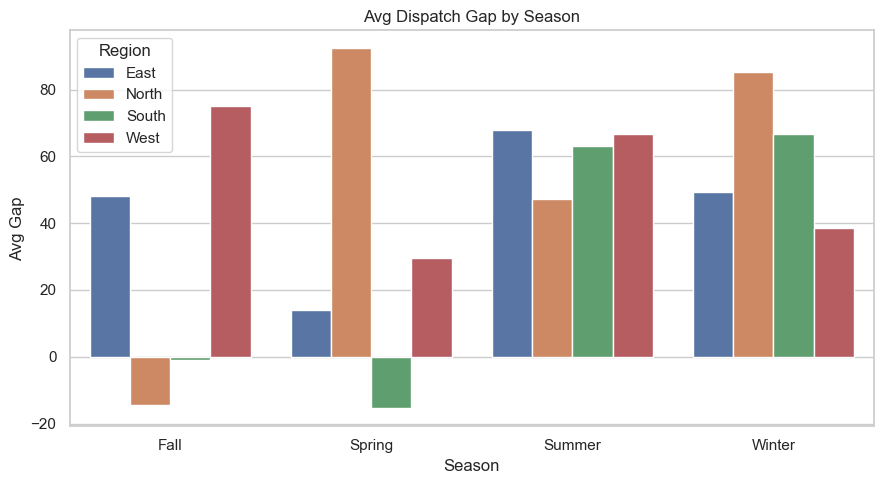

In [30]:
plot_line_chart(df, 'Date', 'Dispatch_Gap', 'Region',
                "Dispatch Gap Over Time", "Date", "Gap")
dispatch_season = df.groupby(['Season', 'Region'])['Dispatch_Gap'].mean().reset_index()
plot_bar_chart(dispatch_season, 'Season', 'Dispatch_Gap', 'Region',
               "Avg Dispatch Gap by Season", "Season", "Avg Gap")


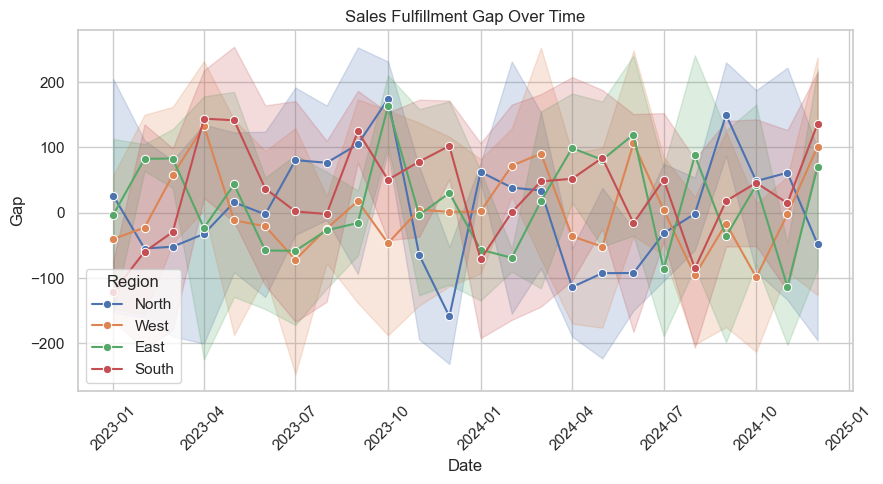

C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1369413589.py:3: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.




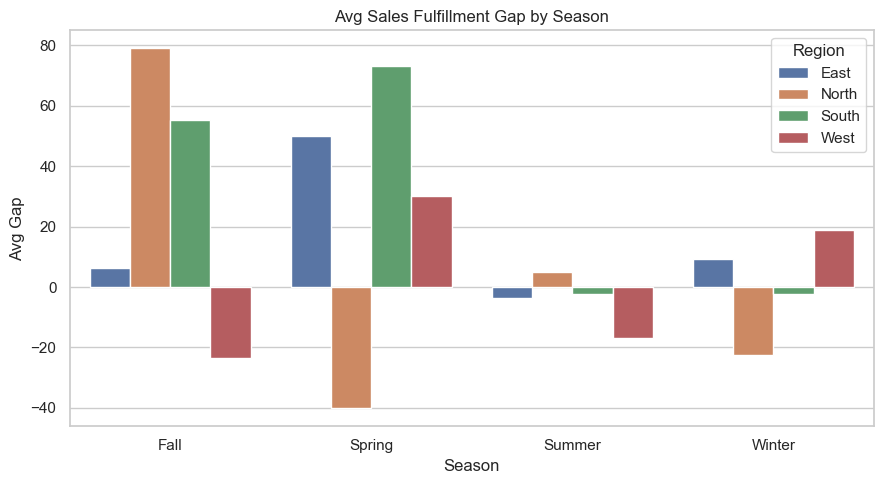

In [31]:
plot_line_chart(df, 'Date', 'Sales_Fulfillment_Gap', 'Region',
                "Sales Fulfillment Gap Over Time", "Date", "Gap")
sales_fulfillment_season = df.groupby(['Season', 'Region'])['Sales_Fulfillment_Gap'].mean().reset_index()
plot_bar_chart(sales_fulfillment_season, 'Season', 'Sales_Fulfillment_Gap', 'Region',
               "Avg Sales Fulfillment Gap by Season", "Season", "Avg Gap")


In [37]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

# Load your data
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Resample by month (or week depending on seasonality pattern)
monthly_data = df['Raw_Material_Ordered'].resample('M').sum()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\846879941.py:12: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



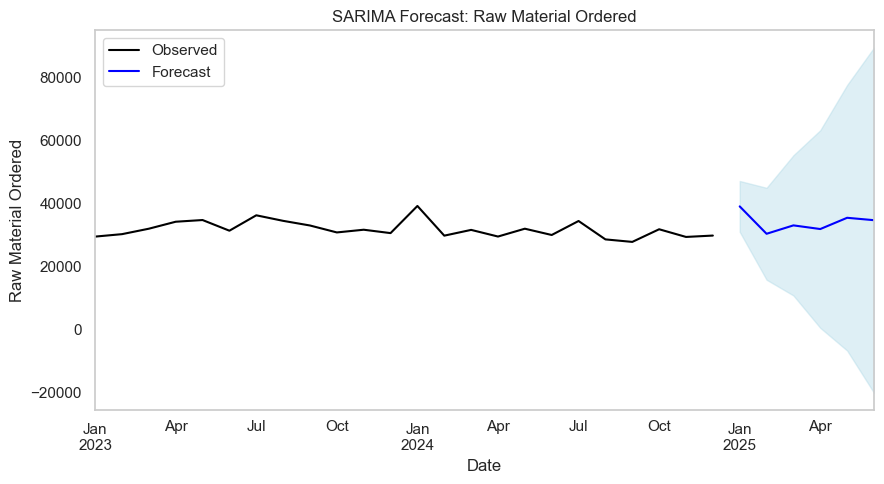

In [48]:
# Build SARIMA model (manual tuning)
model = SARIMAX(monthly_data, 
                order=(1, 1, 1), 
                seasonal_order=(1, 1, 1, 12), 
                enforce_stationarity=False, 
                enforce_invertibility=False)

results = model.fit()

# Forecast next 6 months
forecast = results.get_forecast(steps=6)
forecast_ci = forecast.conf_int()

# Plot
plt.figure(figsize=(9, 5))
monthly_data.plot(label='Observed', color='black')
forecast.predicted_mean.plot(label='Forecast', color='blue')
plt.fill_between(forecast_ci.index, 
                 forecast_ci.iloc[:, 0], 
                 forecast_ci.iloc[:, 1], 
                 color='lightblue', alpha=0.4)
plt.title('SARIMA Forecast: Raw Material Ordered')
plt.legend()
plt.xlabel('Date')
plt.ylabel('Raw Material Ordered')
plt.grid()
plt.tight_layout()
plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\1648665148.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



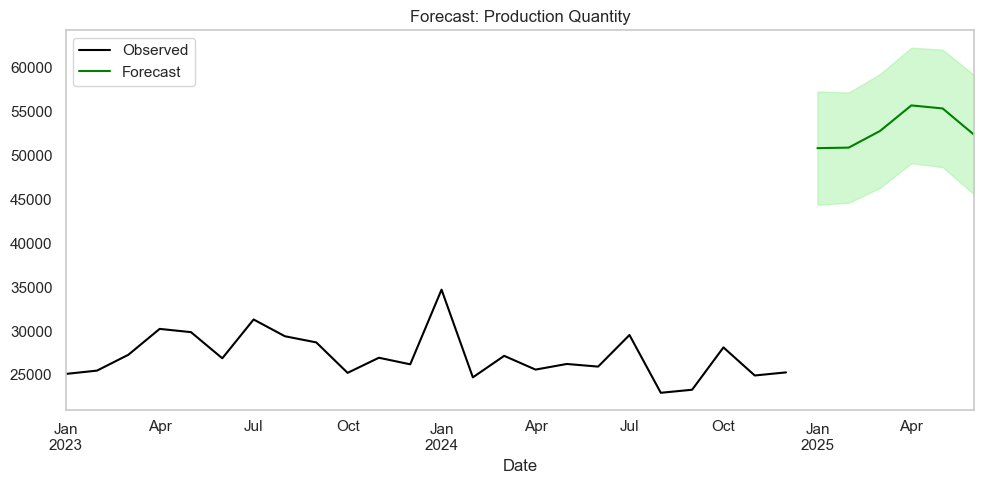

In [39]:
prod_data = df['Production_Qty'].resample('M').sum()
model_prod = SARIMAX(prod_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_prod = model_prod.fit()

forecast_prod = results_prod.get_forecast(steps=6)
ci_prod = forecast_prod.conf_int()

plt.figure(figsize=(10,5))
prod_data.plot(label='Observed', color='black')
forecast_prod.predicted_mean.plot(label='Forecast', color='green')
plt.fill_between(ci_prod.index, ci_prod.iloc[:, 0], ci_prod.iloc[:, 1], color='lightgreen', alpha=0.4)
plt.title('Forecast: Production Quantity')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\3358217171.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



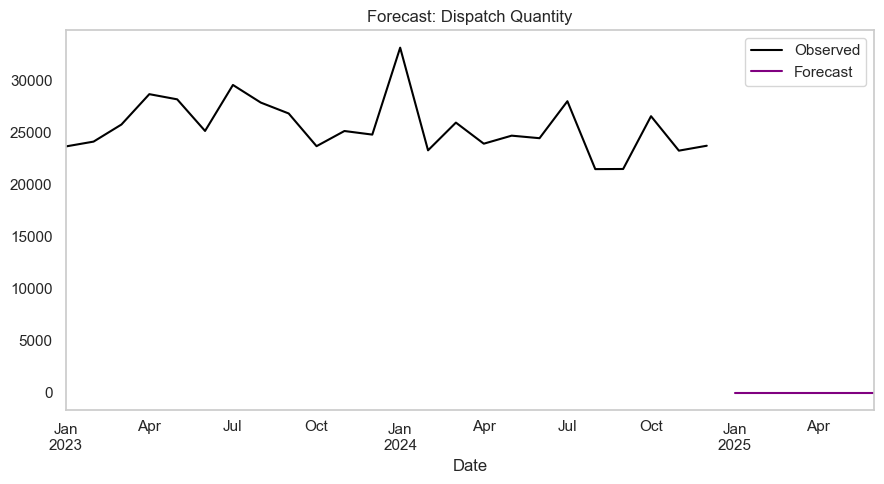

In [47]:
dispatch_data = df['Dispatch_Qty'].resample('M').sum()
model_dispatch = SARIMAX(dispatch_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_dispatch = model_dispatch.fit()

forecast_dispatch = results_dispatch.get_forecast(steps=6)
ci_dispatch = forecast_dispatch.conf_int()

plt.figure(figsize=(9,5))
dispatch_data.plot(label='Observed', color='black')
forecast_dispatch.predicted_mean.plot(label='Forecast', color='purple')
plt.fill_between(ci_dispatch.index, ci_dispatch.iloc[:, 0], ci_dispatch.iloc[:, 1], color='violet', alpha=0.4)
plt.title('Forecast: Dispatch Quantity')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\4294608498.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



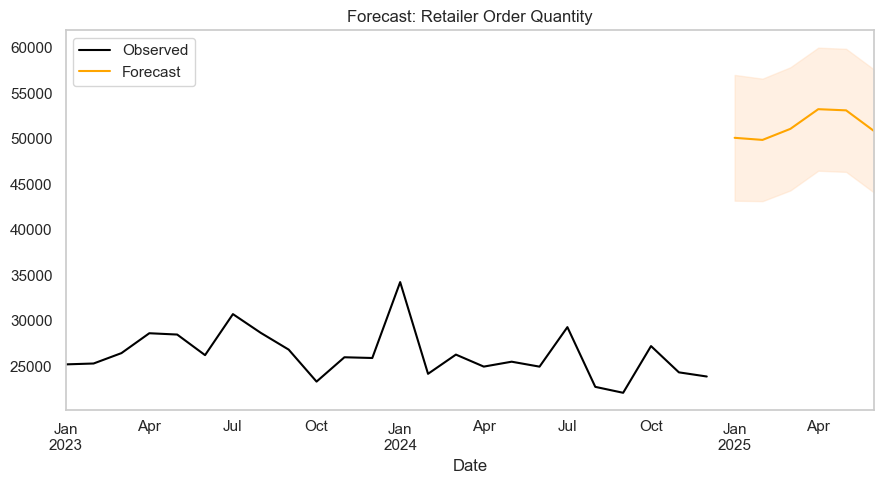

In [44]:
retailer_order = df['Retailer_Order_Qty'].resample('M').sum()
model_ret = SARIMAX(retailer_order, order=(1,1,1), seasonal_order=(1,1,1,12))
results_ret = model_ret.fit()

forecast_ret = results_ret.get_forecast(steps=6)
ci_ret = forecast_ret.conf_int()

plt.figure(figsize=(9,5))
retailer_order.plot(label='Observed', color='black')
forecast_ret.predicted_mean.plot(label='Forecast', color='orange')
plt.fill_between(ci_ret.index, ci_ret.iloc[:, 0], ci_ret.iloc[:, 1], color='peachpuff', alpha=0.4)
plt.title('Forecast: Retailer Order Quantity')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\3008550318.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning:

Non-invertible starting MA parameters found. Using zeros as starting parameters.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.



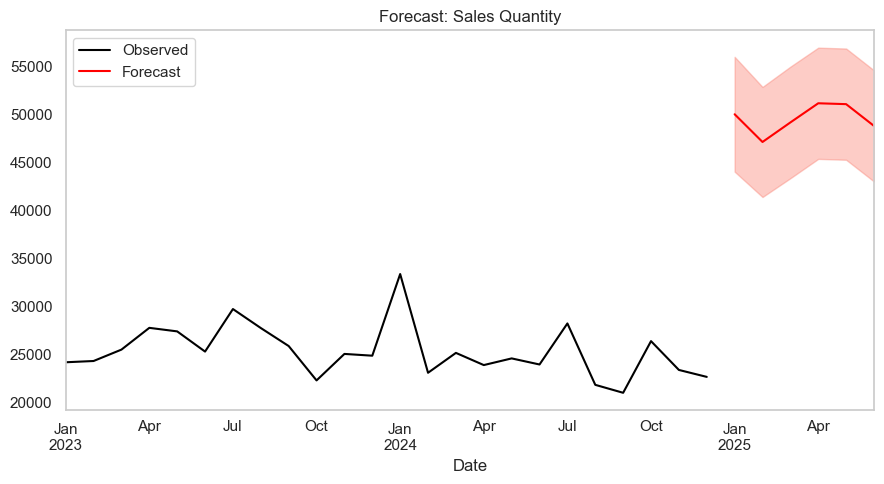

In [46]:
sales_data = df['Sales_Qty'].resample('M').sum()
model_sales = SARIMAX(sales_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_sales = model_sales.fit()

forecast_sales = results_sales.get_forecast(steps=6)
ci_sales = forecast_sales.conf_int()

plt.figure(figsize=(9,5))
sales_data.plot(label='Observed', color='black')
forecast_sales.predicted_mean.plot(label='Forecast', color='red')
plt.fill_between(ci_sales.index, ci_sales.iloc[:, 0], ci_sales.iloc[:, 1], color='salmon', alpha=0.4)
plt.title('Forecast: Sales Quantity')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()


C:\Users\Hp\AppData\Local\Temp\ipykernel_11668\137977673.py:1: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning:

Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.

C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals



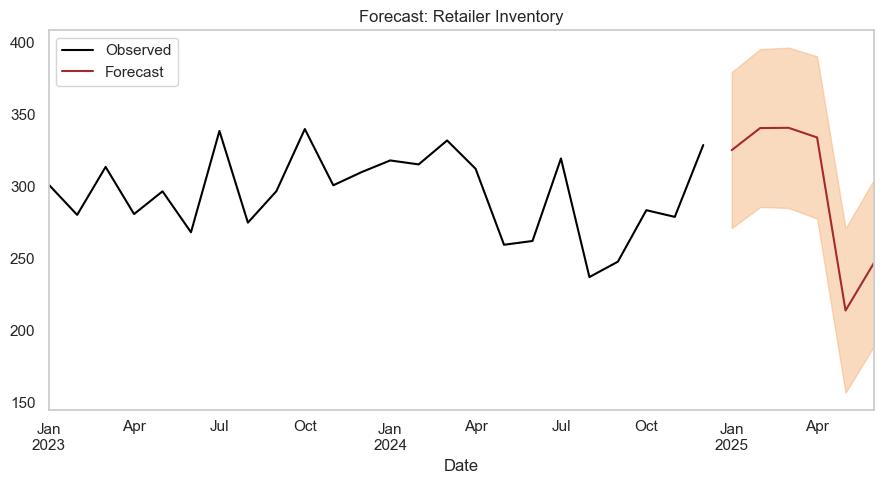

In [45]:
inventory_data = df['Retailer_Inventory'].resample('M').mean()
model_inv = SARIMAX(inventory_data, order=(1,1,1), seasonal_order=(1,1,1,12))
results_inv = model_inv.fit()

forecast_inv = results_inv.get_forecast(steps=6)
ci_inv = forecast_inv.conf_int()

plt.figure(figsize=(9,5))
inventory_data.plot(label='Observed', color='black')
forecast_inv.predicted_mean.plot(label='Forecast', color='brown')
plt.fill_between(ci_inv.index, ci_inv.iloc[:, 0], ci_inv.iloc[:, 1], color='sandybrown', alpha=0.4)
plt.title('Forecast: Retailer Inventory')
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()
